# Example noteboook workflow after refactoring codebase

This notebook outlines the new workflow following on from the refactired codebase.<br> Extensive sections of boilerplate code have been modularised in order to promote faster experimentation and improve both readability and understandability of this repository.

In [ ]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator


## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in ../../data/raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


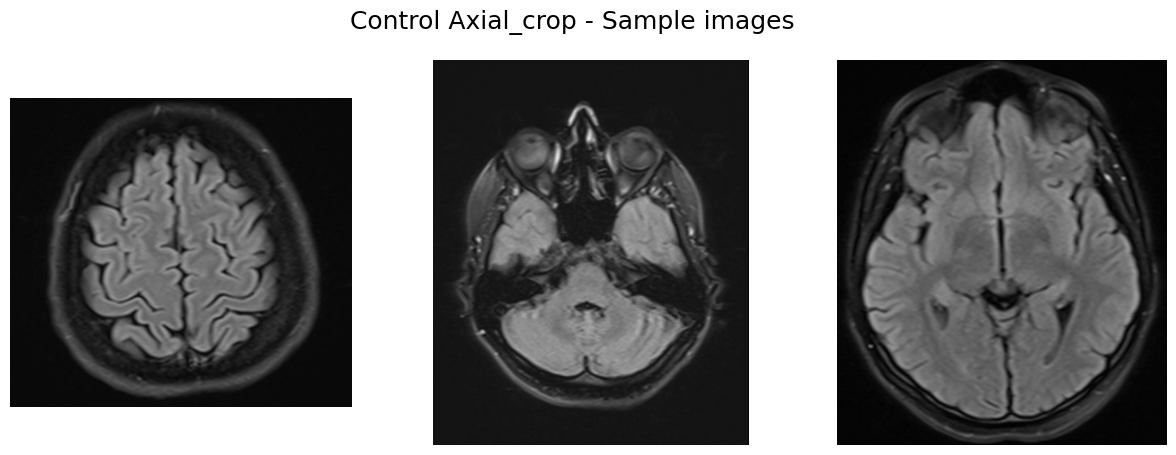

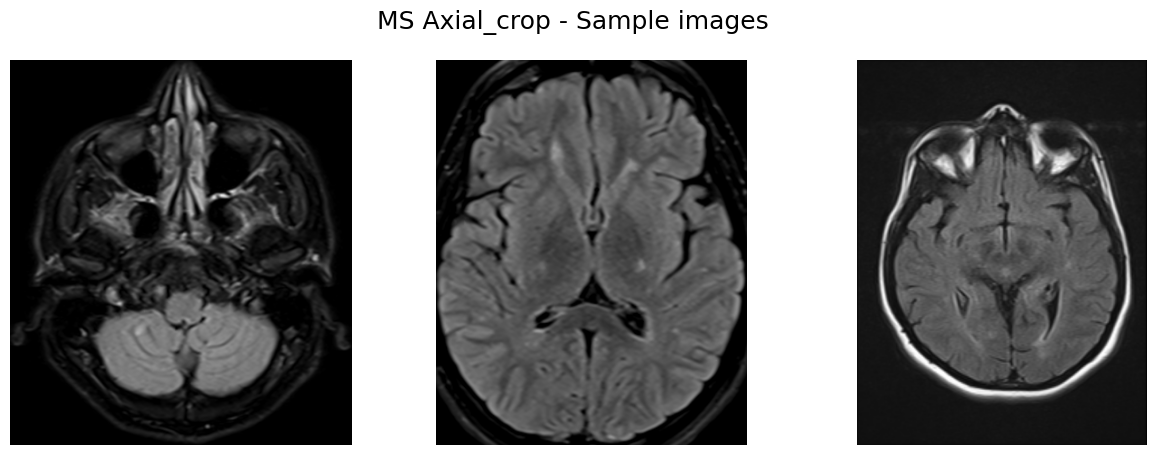

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Training samples: 1321, Testing samples: 331


In [ ]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, test_loader, test_data = data.get_data_loaders(image_paths, labels, train_transform, test_transform)

## Model Instantiation

In [4]:
model = models.get_model()


get_model()>>> 
 BaseResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [5]:
train_losses, train_accuracies = trainer.train_model(model, train_loader)


Epoch 1/15 - Loss: 0.5224 - Acc: 0.7320
Epoch 2/15 - Loss: 0.4453 - Acc: 0.7918
Epoch 3/15 - Loss: 0.3915 - Acc: 0.8168
Epoch 4/15 - Loss: 0.3557 - Acc: 0.8433
Epoch 5/15 - Loss: 0.3474 - Acc: 0.8600
Epoch 6/15 - Loss: 0.3455 - Acc: 0.8410
Epoch 7/15 - Loss: 0.3382 - Acc: 0.8433
Epoch 8/15 - Loss: 0.3244 - Acc: 0.8600
Epoch 9/15 - Loss: 0.3153 - Acc: 0.8622
Epoch 10/15 - Loss: 0.3153 - Acc: 0.8683
Epoch 11/15 - Loss: 0.3329 - Acc: 0.8456
Epoch 12/15 - Loss: 0.3170 - Acc: 0.8622
Epoch 13/15 - Loss: 0.3089 - Acc: 0.8721
Epoch 14/15 - Loss: 0.3106 - Acc: 0.8690
Epoch 15/15 - Loss: 0.2964 - Acc: 0.8728


## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [6]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\refactor\src\evaluator.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.797583081570997
Precision: 0.9565217391304348
Recall: 0.5076923076923077
Confusion Matrix:
 [[198   3]
 [ 64  66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.99      0.86       201
           1       0.96      0.51      0.66       130

    accuracy                           0.80       331
   macro avg       0.86      0.75      0.76       331
weighted avg       0.83      0.80      0.78       331



## Model Prediction Visualisation

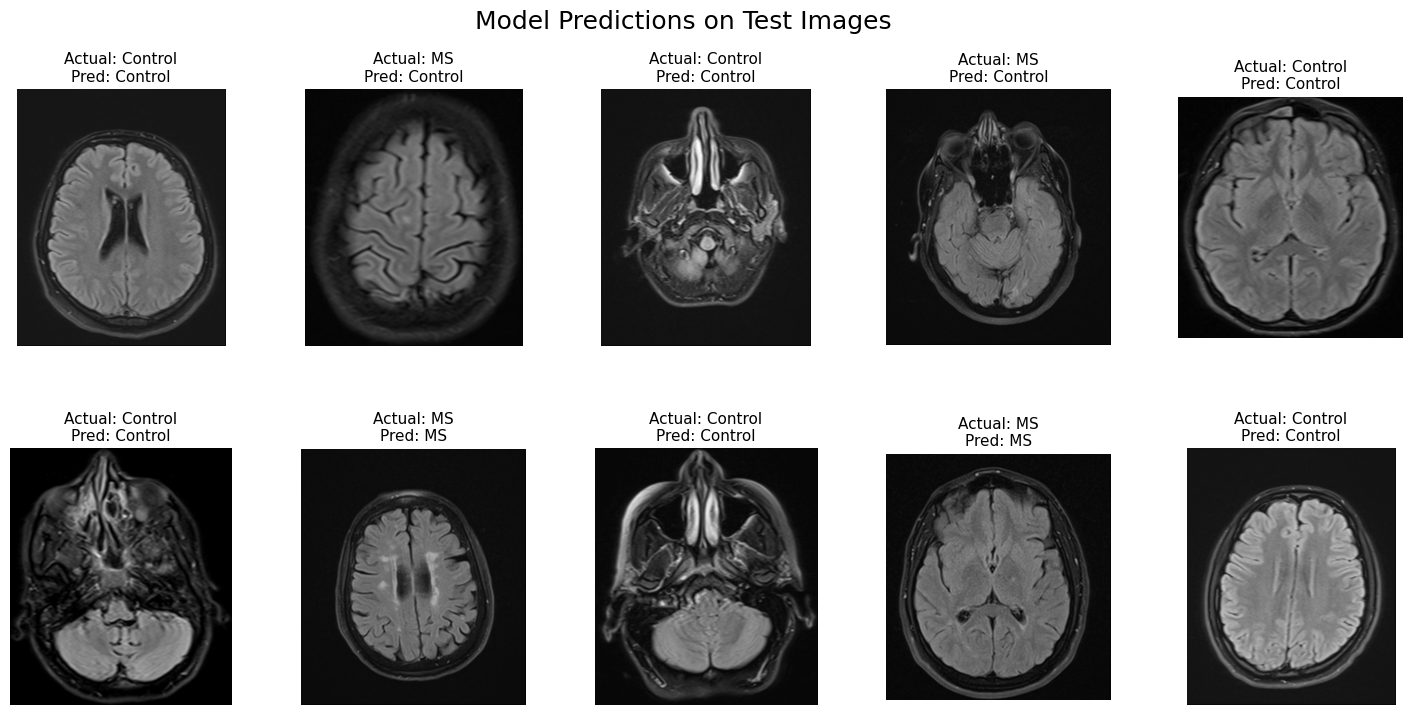

In [7]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)